In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [2]:
NUM_BITS = 20
Z_BASIS = 'Z'
X_BASIS = 'X'

In [3]:
alice_bits = np.random.randint(2, size=NUM_BITS)
alice_bases = np.random.choice([Z_BASIS, X_BASIS], size=NUM_BITS)
print(f"Alice's bits:  {alice_bits}")
print(f"Alice's bases: {alice_bases}")

Alice's bits:  [1 0 1 1 0 0 0 1 0 1 0 1 0 1 1 0 1 1 1 0]
Alice's bases: ['X' 'Z' 'X' 'X' 'X' 'X' 'Z' 'X' 'X' 'Z' 'X' 'Z' 'X' 'Z' 'X' 'X' 'Z' 'Z'
 'X' 'Z']


Example: Circuit for 3rd qubit


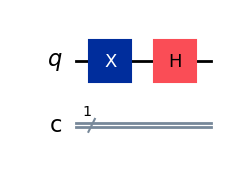

In [4]:
def encode_qubits(bits, bases):
    qubits = []
    for i in range(len(bits)):
        qc = QuantumCircuit(1, 1)
        if bits[i] == 1:
            qc.x(0)
        if bases[i] == X_BASIS:
            qc.h(0)
        qubits.append(qc)
    return qubits

alice_qubits = encode_qubits(alice_bits, alice_bases)
# Let's draw the 3rd qubit as an example
print("Example: Circuit for 3rd qubit")
alice_qubits[2].draw('mpl')

In [5]:
bob_bases = np.random.choice([Z_BASIS, X_BASIS], size=NUM_BITS)
print(f"Bob's bases:   {bob_bases}")

def measure_qubits(qubits, bases):
    backend = AerSimulator()
    measured_bits = []
    for i in range(len(qubits)):
        qc = qubits[i]
        if bases[i] == X_BASIS:
            qc.h(0)
        qc.measure(0, 0)
        job = backend.run(qc, shots=1, memory=True)
        measured_bit = int(job.result().get_memory()[0])
        measured_bits.append(measured_bit)
    return np.array(measured_bits)

bob_measured_bits = measure_qubits(alice_qubits, bob_bases)
print(f"Bob's results: {bob_measured_bits}")

Bob's bases:   ['Z' 'X' 'X' 'Z' 'X' 'X' 'X' 'X' 'Z' 'Z' 'Z' 'Z' 'Z' 'X' 'Z' 'Z' 'Z' 'Z'
 'Z' 'Z']
Bob's results: [1 1 1 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 1 0]


In [6]:
matching_indices = np.where(alice_bases == bob_bases)[0]
alice_sifted_key = alice_bits[matching_indices]
bob_sifted_key = bob_measured_bits[matching_indices]

print(f"Alice's bases: {alice_bases}")
print(f"Bob's bases:   {bob_bases}")
print(f"Matching idx:  {matching_indices}")
print("-" * 20)
print(f"Alice's sifted key: {alice_sifted_key}")
print(f"Bob's sifted key:   {bob_sifted_key}")

# --- Cell 7: Step 5 - Error Checking ---
errors = np.sum(alice_sifted_key != bob_sifted_key)
error_rate = errors / len(alice_sifted_key) if len(alice_sifted_key) > 0 else 0.0
print(f"Number of errors: {errors}")
print(f"Error rate: {error_rate:.2%}")
if error_rate > 0:
    print("Error rate is non-zero! Eavesdropper likely present.")
else:
    print("No errors found. The key is secure.")

Alice's bases: ['X' 'Z' 'X' 'X' 'X' 'X' 'Z' 'X' 'X' 'Z' 'X' 'Z' 'X' 'Z' 'X' 'X' 'Z' 'Z'
 'X' 'Z']
Bob's bases:   ['Z' 'X' 'X' 'Z' 'X' 'X' 'X' 'X' 'Z' 'Z' 'Z' 'Z' 'Z' 'X' 'Z' 'Z' 'Z' 'Z'
 'Z' 'Z']
Matching idx:  [ 2  4  5  7  9 11 16 17 19]
--------------------
Alice's sifted key: [1 0 0 1 1 1 1 1 0]
Bob's sifted key:   [1 0 0 1 1 1 1 1 0]
Number of errors: 0
Error rate: 0.00%
No errors found. The key is secure.
